## Read Sentinel-2 files from public bucket

* Author: Gonzalo Mateo-García

This notebook shows how to read a Sentinel-2 SAFE file from the public Google bucket and reading a subset of it.

In [1]:
import os
from georeader.readers import S2_SAFE_reader

os.environ["GS_NO_SIGN_REQUEST"] = "YES"

# Donwload key from next line link to access the buckets and requester pays requests to public bucket (this is needed to query Sentinel-2 data)
# This is required to do advaced operations in the GCP bucket
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "path/to/file.json"
# os.environ["GS_USER_PROJECT"] = "project-name"
# S2_SAFE_reader.DEFAULT_REQUESTER_PAYS=True

In [2]:
%%time

safe_file = "S2B_MSIL1C_20220527T030539_N0400_R075_T49SGV_20220527T051042.SAFE"
s2_safe_folder = S2_SAFE_reader.s2_public_bucket_path(safe_file, check_exists=False)

print(f"File is located at: {s2_safe_folder}")

s2obj = S2_SAFE_reader.s2loader(s2_safe_folder, out_res=10)

os.makedirs("deleteme",exist_ok=True)
s2obj = s2obj.cache_product_to_local_dir("deleteme")

s2obj

File is located at: gs://gcp-public-data-sentinel-2/tiles/49/S/GV/S2B_MSIL1C_20220527T030539_N0400_R075_T49SGV_20220527T051042.SAFE


  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 10417.64it/s]

CPU times: user 517 ms, sys: 72.3 ms, total: 589 ms
Wall time: 960 ms


 
         deleteme/S2B_MSIL1C_20220527T030539_N0400_R075_T49SGV_20220527T051042.SAFE
         Transform: | 10.00, 0.00, 699960.00|
| 0.00,-10.00, 4000020.00|
| 0.00, 0.00, 1.00|
         Shape: (13, 10980, 10980)
         Resolution: (10.0, 10.0)
         Bounds: (699960.0, 3890220.0, 809760.0, 4000020.0)
         CRS: EPSG:32649
         bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']
         fill_value_default: 0
        

Select the bands and bounds to read and trigger `load` (to read the data in memory)

In [3]:
%%time
from georeader import read
bounds_read = (759760.0, 3940220.0, 799760.0, 3960220.0)

s2obj_3bands = s2obj.read_from_band_names(["B04", "B03", "B02"])
data = read.read_from_bounds(s2obj_3bands, bounds_read) # This does not trigger the download of the data
data_memory = data.load() # this triggers download only for the selected bands and within the bounds
data_memory

CPU times: user 24.1 s, sys: 769 ms, total: 24.8 s
Wall time: 2.14 s


 
         Transform: | 10.00, 0.00, 759760.00|
| 0.00,-10.00, 3960220.00|
| 0.00, 0.00, 1.00|
         Shape: (3, 2000, 4000)
         Resolution: (10.0, 10.0)
         Bounds: (759760.0, 3940220.0, 799760.0, 3960220.0)
         CRS: EPSG:32649
         fill_value_default: 0
        

The `numpy.array` is stored in the `values` property.

In [4]:
%%time
data_memory.values

CPU times: user 18 μs, sys: 0 ns, total: 18 μs
Wall time: 24.1 μs


array([[[1314, 1139, 1156, ..., 1517, 1730, 1561],
        [1309, 1142, 1274, ..., 1581, 1730, 1508],
        [1335, 1288, 1526, ..., 1659, 1688, 1395],
        ...,
        [1510, 1539, 1567, ..., 1012, 1016, 1028],
        [1479, 1514, 1545, ...,  974,  952,  954],
        [1517, 1515, 1555, ...,  951,  952,  946]],

       [[1395, 1271, 1275, ..., 1460, 1567, 1423],
        [1355, 1260, 1347, ..., 1450, 1584, 1385],
        [1396, 1360, 1502, ..., 1483, 1569, 1326],
        ...,
        [1570, 1585, 1595, ..., 1159, 1160, 1147],
        [1563, 1572, 1578, ..., 1151, 1133, 1105],
        [1555, 1576, 1562, ..., 1147, 1135, 1112]],

       [[1398, 1301, 1320, ..., 1560, 1629, 1459],
        [1386, 1319, 1403, ..., 1608, 1605, 1418],
        [1417, 1401, 1544, ..., 1633, 1561, 1377],
        ...,
        [1690, 1699, 1687, ..., 1216, 1218, 1215],
        [1665, 1670, 1666, ..., 1213, 1208, 1195],
        [1653, 1647, 1652, ..., 1204, 1208, 1191]]],
      shape=(3, 2000, 4000), dtype=ui

Plot the data that we have read

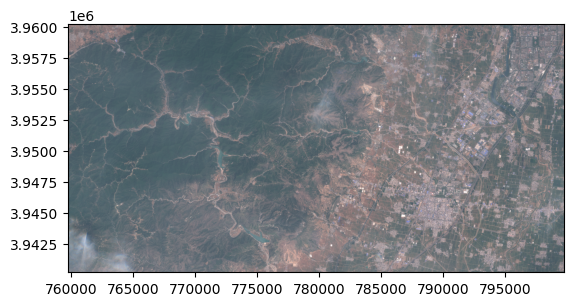

CPU times: user 2.24 s, sys: 256 ms, total: 2.5 s
Wall time: 2.51 s


<Axes: >

In [5]:
%%time

import rasterio.plot as rstplt
import numpy as np

# From processing baseline PB04.00  values have an offset of 1_000. 
# This is handled automatically by the load function
rstplt.show(np.clip(data_memory.values/3_000,0,1), transform=data_memory.transform)

In [6]:
# import shutil

# if os.path.exists("deleteme"):
#     shutil.rmtree("deleteme")

## Licence
The georeader package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

`georeader` tutorials and notebooks are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt).

 If you find this work useful please cite:

```
@article{portales-julia_global_2023,
	title = {Global flood extent segmentation in optical satellite images},
	volume = {13},
	issn = {2045-2322},
	doi = {10.1038/s41598-023-47595-7},
	number = {1},
	urldate = {2023-11-30},
	journal = {Scientific Reports},
	author = {Portalés-Julià, Enrique and Mateo-García, Gonzalo and Purcell, Cormac and Gómez-Chova, Luis},
	month = nov,
	year = {2023},
	pages = {20316},
}
```